<a href="https://colab.research.google.com/github/228andrey228/Ya_ML/blob/main/%D0%98%D1%81%D1%81%D0%BB%D0%B5%D0%B4%D0%BE%D0%B2%D0%B0%D1%82%D0%B5%D0%BB%D1%8C%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%D0%BD%D0%B0_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torch import nn
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from torchsummary import summary
import sklearn.metrics as metrics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [ ]:
# 1) Скачивание датасета MNIST

train_dataset = datasets.MNIST(root='mnist', train=True, download=True, transform=transforms.Compose([transforms.ToTensor(), nn.Flatten(0,2)]))
test_dataset = datasets.MNIST(root='mnist', train=False, download=True, transform=transforms.Compose([transforms.ToTensor(), nn.Flatten(0,2)]))

print(train_dataset, '\n', '1-я цифра: ', train_dataset[0][0].size(), train_dataset[0][1], '\n')
print(test_dataset, '\n', '1-я цифра: ', test_dataset[0][0].size(), test_dataset[0][1], '\n')

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9.91M/9.91M [00:00<00:00, 11.5MB/s]


Extracting mnist/MNIST/raw/train-images-idx3-ubyte.gz to mnist/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28.9k/28.9k [00:00<00:00, 343kB/s]


Extracting mnist/MNIST/raw/train-labels-idx1-ubyte.gz to mnist/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1.65M/1.65M [00:00<00:00, 3.19MB/s]


Extracting mnist/MNIST/raw/t10k-images-idx3-ubyte.gz to mnist/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4.54k/4.54k [00:00<00:00, 12.9MB/s]

Extracting mnist/MNIST/raw/t10k-labels-idx1-ubyte.gz to mnist/MNIST/raw

Dataset MNIST
    Number of datapoints: 60000
    Root location: mnist
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Flatten(start_dim=0, end_dim=2)
           ) 
 1-я цифра:  torch.Size([784]) 5 

Dataset MNIST
    Number of datapoints: 10000
    Root location: mnist
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Flatten(start_dim=0, end_dim=2)
           ) 
 1-я цифра:  torch.Size([784]) 7 



In [ ]:
# 2) Модель нейросети

# 4 различные модели:

def models(number):
    if number == 1:                               # 1) 2 скрытых слоя, функция активации - ReLU, без Dropout и BatchNorm
        model_1_2HL_ReLU = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        ).to(device)
        print('\nmodel_1_2HL_ReLU\n', summary(model_1_2HL_ReLU, (1, 784)))
        return model_1_2HL_ReLU

    elif number == 2:                             # 2) 1 скрытый слой, функция активации - ReLU и Sigmoid, без Dropout и BatchNorm
        model_2_1HL_Sigm = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.Sigmoid(),
            nn.Linear(512, 10),
        ).to(device)
        print('\nmodel_2_1HL_Sigm\n', summary(model_2_1HL_Sigm, (1, 784)))
        return model_2_1HL_Sigm

    elif number == 3:                             # 3) 1 скрытый слой, функция активации - ReLU, без Dropout и BatchNorm
        model_3_1HL_ReLU = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        ).to(device)
        print('\nmodel_3_1HL_ReLU\n', summary(model_3_1HL_ReLU, (1, 784)))
        return model_3_1HL_ReLU

    else:                                         # 4) 1 скрытый слой, функция активации - ReLU, с BatchNorm
        model_4_1HL_ReLU_BNorm = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        ).to(device)
        print('\nmodel_4_1HL_ReLU_BNorm\n')       # Не получается вывести summary, жалуется на BatchNorm
        return model_4_1HL_ReLU_BNorm

In [ ]:
# Основная функция обучения

def run(model, dataloader, loss_function, wanted_epochs, optimizer=None):
    global shown_epochs       # для таблицы
    flag_for_show = False     # для таблицы
    total_loss = 0            # для графика по бачам

    if shown_epochs < wanted_epochs:     # для таблицы
        flag_for_show = True

    if optimizer == None:
        model.eval()
        y_true = np.array([])    # для метрик
        y_pred = np.array([])
    else:
        model.train()
        if flag_for_show:     # для таблицы
            size_train = len(dataloader.dataset)
            print(f"\nEpoch {i+1}\n-------------------------------")

    for batch, (x, y) in enumerate(dataloader):     # batch для таблицы
        pred = model(x.to(device))
        y = y.to(device)
        loss = loss_function(pred, y)
        total_loss += loss.item()      # для графика по бачам

        if optimizer != None:
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            if flag_for_show and (batch % 100 == 0):     # для таблицы
                loss = loss.item()
                current = batch * batch_size + len(x)
                print(f'loss: {loss:>7f} [{current:>5d}/{size_train:>5d}]')

        else:        # для метрик
            y, pred = y.to('cpu'), pred.to('cpu')
            y_true = np.append(y_true, y)
            y_pred = np.append(y_pred, pred.argmax(1))

    total_loss /= len(dataloader)     # для графика по бачам и для таблицы

    if flag_for_show:        # для таблицы
        shown_epochs += 0.5

    if optimizer == None:        # для графика по бачам и для таблицы
        accuracy = metrics.accuracy_score(y_true, y_pred)

        if flag_for_show:        # для таблицы            # ((j - 1) == i) or
            print(f"\nEpoch {i+1}) Test Error ->  Accuracy: {(100*accuracy):>0.1f}%, Avg loss: {total_loss:>8f}")

        if i == epochs - 1:        # для метрик
            precision = metrics.precision_score(y_true, y_pred, average='weighted')
            recall = metrics.recall_score(y_true, y_pred, average='weighted')
            f1_score = metrics.f1_score(y_true, y_pred, average='weighted')

            return total_loss, accuracy, precision, recall, f1_score

        return total_loss, accuracy, 0, 0, 0

    return total_loss

In [ ]:
# Функции графиков

def plot(title, object, num_plot, num_model):
    plt.subplot(4, 3, num_plot)
    plt.title(title)
    plt.plot(np.arange(len(object[num_model])), object[num_model])
    plt.yscale('log')
    plt.grid()


def show_losses(train_loss_hist, test_loss_hist, test_accuracy_hist):
    clear_output()

    plt.figure(figsize=(20,15))

    # M1
    plot('Train Loss M1', train_loss_hist, 1, 'M1')
    plot('Test Loss M1', test_loss_hist, 2, 'M1')
    plot('Test accuracy M1', test_accuracy_hist, 3, 'M1')

    # M2
    plot('Train Loss M2', train_loss_hist, 4, 'M2')
    plot('Test Loss M2', test_loss_hist, 5, 'M2')
    plot('Test accuracy M2', test_accuracy_hist, 6, 'M2')

    # M3
    plot('Train Loss M3', train_loss_hist, 7, 'M3')
    plot('Test Loss M3', test_loss_hist, 8, 'M3')
    plot('Test accuracy M3', test_accuracy_hist, 9, 'M3')

    # M4
    plot('Train Loss M4', train_loss_hist, 10, 'M4')
    plot('Test Loss M4', test_loss_hist, 11, 'M4')
    plot('Test accuracy M4', test_accuracy_hist, 12, 'M4')

    plt.show()

In [ ]:
# Вспомогательная функция

def Appender(lists, elements):
    for i in range(len(lists)):
        lists[i].append(elements[i])

In [ ]:
# 4) Обучение модели

# списки для итоговой таблицы
num_model = [1, 2, 3, 4]
Features = ['2 hidden layers, ReLU activation', '1 hidden layer, ReLU+Sigmoid act.', '1 hidden layer, ReLU act.', '1 hidden layer, ReLU act., BatchNorm1d']
time_to_complete = []
avg_losses = []
Accuracies = []
Precisions = []
Recalls = []
F1_scores = []

# Гиперпараметры модели
learning_rates = [1e-1, 1e-2, 1e-3]
batch_sizes = [50, 100]
epochses = [2, 10, 50, 100]

loss_fn = nn.CrossEntropyLoss()

# для графиков
train_loss_hist = {'M1': [], 'M2': [], 'M3': [], 'M4': []}
test_loss_hist = {'M1': [], 'M2': [], 'M3': [], 'M4': []}
test_accuracy_hist = {'M1': [], 'M2': [], 'M3': [], 'M4': []}

In [ ]:
# Обучение: проходимся по каждой модели, фиксируя данные для итога

for num in num_model:
    s = time.time()

    model = models(num)
    learning_rate = learning_rates[1]
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    batch_size = batch_sizes[1]
    epochs = epochses[3]
    shown_epochs = 0         # для таблицы
    wanted_epochs = 1        # для таблицы

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)
    print('Длина train_loader: ', len(train_loader))
    print('Длина test_loader: ', len(test_loader))
    for x, y in train_loader:
        print('Batch 1:')
        print('x:', x.size())
        print('y:', y.size())
        break

    # j = epochs // 10
    for i in range(epochs):
        train_loss = run(model, train_loader, loss_fn, wanted_epochs, optimizer)
        train_loss_hist[f'M{num}'].append(train_loss)
        test_loss, test_accuracy, test_precision, test_recall, test_f1_score = run(model, test_loader, loss_fn, wanted_epochs)
        test_loss_hist[f'M{num}'].append(test_loss)
        test_accuracy_hist[f'M{num}'].append(test_accuracy)

        # if (j - 1) == i or (epochs < 10):
        #     show_losses(train_loss_hist, test_loss_hist, test_accuracy_hist)
        #     j += (epochs // 10)

    t = time.time() - s
    duration = f'{t:.3f} s'

    Appender([avg_losses, Accuracies, Precisions, Recalls, F1_scores, time_to_complete], [test_loss, test_accuracy, test_precision, test_recall, test_f1_score, duration])
    print('\nDone!\n\n')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1               [-1, 1, 512]         401,920
              ReLU-2               [-1, 1, 512]               0
            Linear-3               [-1, 1, 512]         262,656
              ReLU-4               [-1, 1, 512]               0
            Linear-5               [-1, 1, 512]         262,656
              ReLU-6               [-1, 1, 512]               0
            Linear-7                [-1, 1, 10]           5,130
Total params: 932,362
Trainable params: 932,362
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.02
Params size (MB): 3.56
Estimated Total Size (MB): 3.58
----------------------------------------------------------------

model_1_2HL_ReLU
 None
Длина train_loader:  600
Длина test_loader:  100
Batch 1:
x: torch.Size([100, 784]

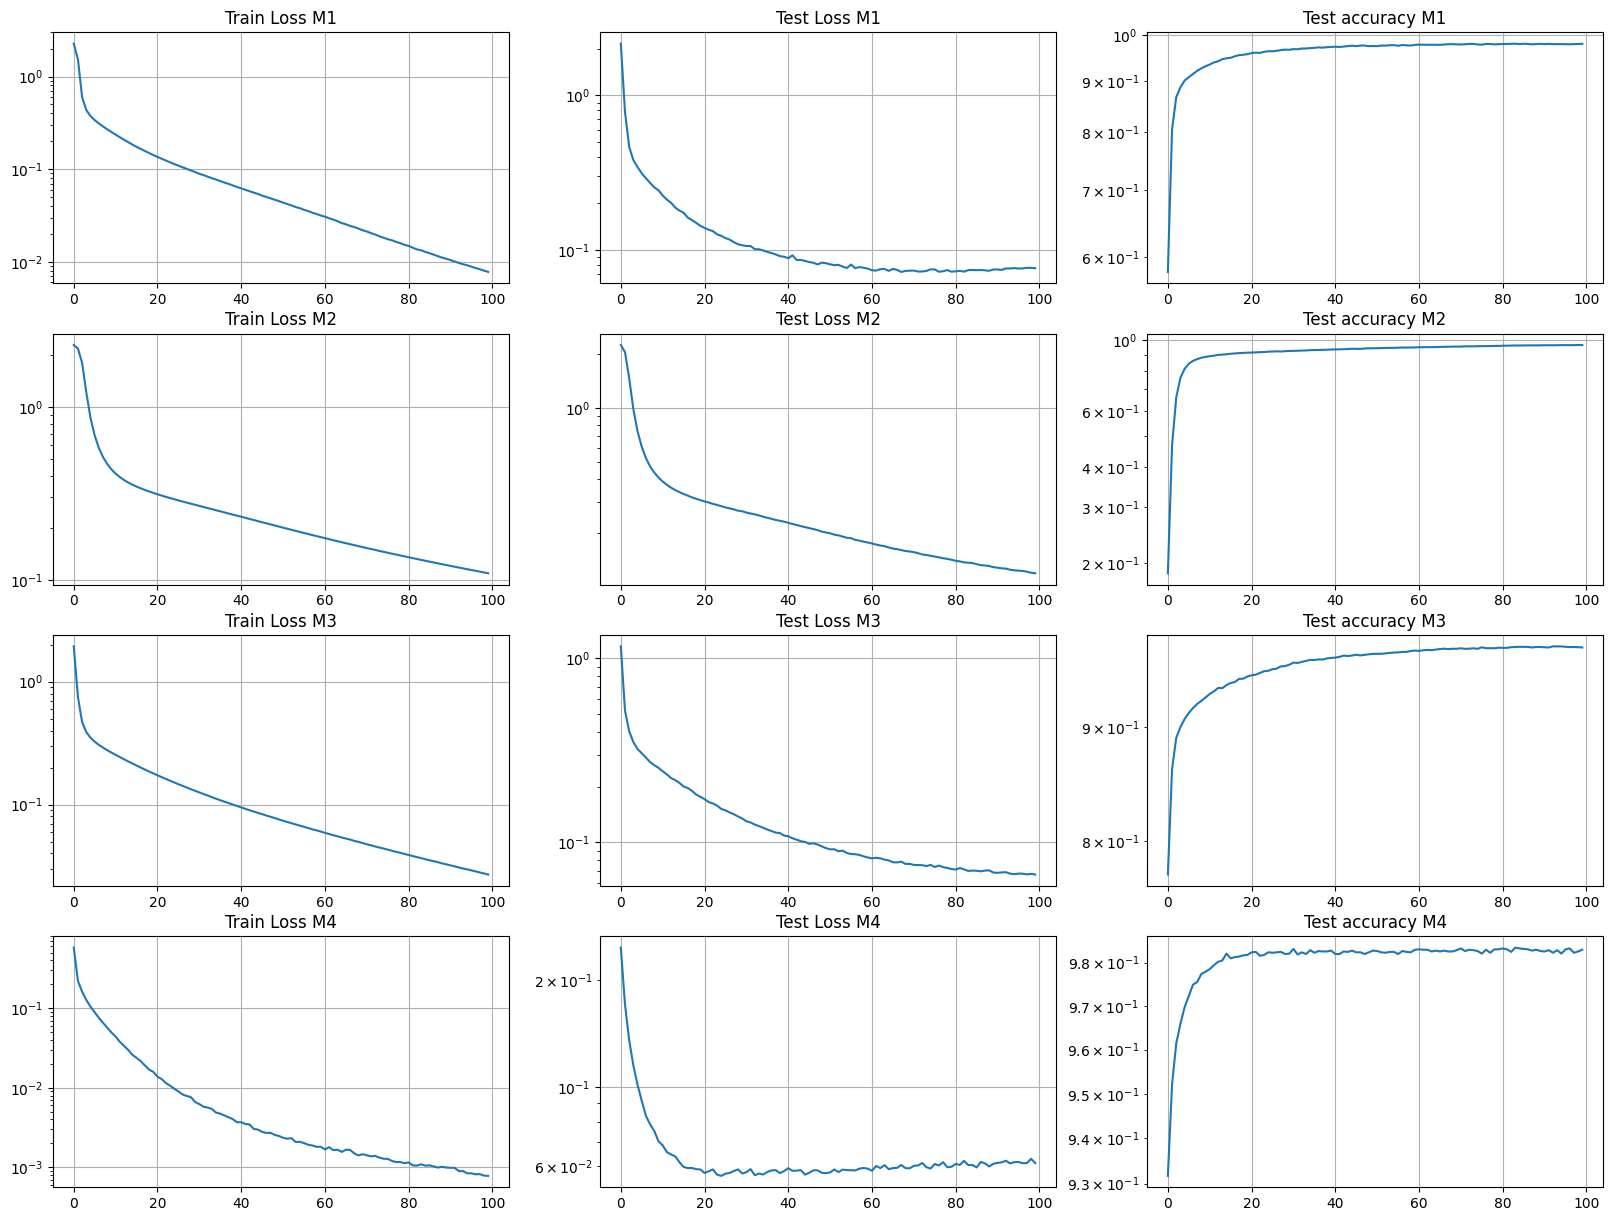

In [ ]:
show_losses(train_loss_hist, test_loss_hist, test_accuracy_hist)

In [ ]:
# 5) Подводим итоги

Hyperparameters = [f'SGD lr: {learning_rate}', f'Epochs: {epochs}', f'Batch size: {batch_size}', 'Num of HL neurons: 512']

table = pd.DataFrame({'Const hyperparameters': Hyperparameters, 'Model': num_model, 'Features': Features, 'Duration': time_to_complete, 'Avg loss': avg_losses, 'Accuracy': Accuracies, 'Precision': Precisions, 'Recall': Recalls, 'F1-score': F1_scores})
print(table)

    Const hyperparameters  Model                                Features  \
0            SGD lr: 0.01      1        2 hidden layers, ReLU activation   
1             Epochs: 100      2       1 hidden layer, ReLU+Sigmoid act.   
2         Batch size: 100      3               1 hidden layer, ReLU act.   
3  Num of HL neurons: 512      4  1 hidden layer, ReLU act., BatchNorm1d   

    Duration  Avg loss  Accuracy  Precision  Recall  F1-score  
0  891.133 s  0.076046    0.9795   0.979524  0.9795  0.979497  
1  879.016 s  0.119560    0.9647   0.964704  0.9647  0.964667  
2  863.966 s  0.066847    0.9774   0.977422  0.9774  0.977398  
3  864.175 s  0.061170    0.9830   0.982998  0.9830  0.982994  


# **Вывод:**
---
Сравним по итогам обучения 4 модели нейронной сети.
---

1-я модель имеет 2 скрытых слоя, активация - ReLU;

2-я: 1 скрытый слой, активации - ReLU затем Sigmoid;

3-я: 1 скрытый слой, активация - ReLU;

4-я: 1 скрытый слой, активация - ReLU, BatchNorm от переобучения.

Все модели имеют по 512 нейронов в скрытых слоях, обучались на 100 эпохах, был применен стохастический градиентный спуск с шагом 0.01 и размером батчей - 100.


---

Время обучения:

Дольше остальных обучалась 1-я модель, следовательно чем больше слоев - тем дольше обучение. Затем по времени идут 3 модели с одним скрытым слоем, из них дольше всех выполнялась модель с Sigmoid активацией. Что Dropout, что Batchnorm абсолютно не повлияли на скорость обучения.


---

Результаты обучения: (данные тестовой выборки)

    Рейтинг моделей:
    1) M4:  Loss - 0.061; Metrics - 98.3%
    2) M3:  Loss - 0.067; Metrics - 97.7%
    3) M1:  Loss - 0.076; Metrics - 97.9%
    4) M2:  Loss - 0.119; Metrics - 96.5%

За счёт использования Batchnorm, 4 модели удалось лучше приблизить лосс к 0 и повысить метрики лучше остальных моделей. Так что, в сравнении с архитектурами остальных моделей (3 модель идентична 4 за исключением отсутствия Batchnorm), выгоднее использовать Batchnorm, чем не использовать. В то же время, глядя на график, лосс 4 модели хоть и стал низким по сравнению с 3 моделью, но прекратил падение в районе 20 эпохи из 100, а лосс 3 - продолжает опускаться на момент 100 эпохи. Возможно, 3 модель покажет лучшие результаты при увеличении числа эпох, но 4 модели для улучшения достаточно лишь на порядок уменьшить learning-rate в SGD.

1-я модель с бОльшим числом скрытых слоёв, чем в остальных моделях, не улучшила бы свой результат при увеличении числа эпох, так как по графику видно, что лосс в конце уже начал возрастать, в то время как на графиках 2 и 3 моделей будущее лосса неясно, и скорее всего он бы продолжил падать при увеличении числа эпох.

2-я модель отличается от остальных в однократном использовании Sigmoid активации, что сильно сказалось на результате обучения: оно длилось дольше. Возможно, при увеличении числа эпох можно добиться лучших результатов, так как график продолжает убывать.



---

Итого, для данной задачи не требуется сложной архитектуры, минимальное число слоев, наипростейшие функции активаций будут выгоднее более сложных, а также использование Batchnorm или Dropout поможет с переобучением и ускорит падение функции ошибки. 4 модель - лучшая в моём эксперименте.